<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/Workshop3_chelghoum_gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# Dataset: Gapminder
# Platform: Google Colab
# ==========================================================
# ----------------------------------------------------------
# Import analysis and visualization libraries
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# ----------------------------------------------------------
# Upload the dataset in Google Colab
# ----------------------------------------------------------
from google.colab import files
uploaded_files = files.upload()

Saving gapminder.csv to gapminder.csv


In [3]:
# ----------------------------------------------------------
# Load CSV file into a DataFrame
# ----------------------------------------------------------
file_name = list(uploaded_files.keys())[0]
df = pd.read_csv("gapminder.csv")

print("Dataset overview:")
display(df.head())

print("\nDataset information:")
print(df.info())


Dataset overview:


,Unnamed: 0,country,year,population,continent,life_exp,gdp_cap
0,11,Afghanistan,2007,31889923,Asia,43.828,974.580338
1,23,Albania,2007,3600523,Europe,76.423,5937.029526
2,35,Algeria,2007,33333216,Africa,72.301,6223.367465
3,47,Angola,2007,12420476,Africa,42.731,4797.231267
4,59,Argentina,2007,40301927,Americas,75.320,12779.379640



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  142 non-null    int64  
 1   country     142 non-null    object 
 2   year        142 non-null    int64  
 3   population  142 non-null    int64  
 4   continent   142 non-null    object 
 5   life_exp    142 non-null    float64
 6   gdp_cap     142 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 7.9+ KB
None


In [4]:
# ----------------------------------------------------------
# Data cleaning and type adjustments
# ----------------------------------------------------------
df.dropna(inplace=True)

# Convert numerical columns explicitly
numeric_cols = ['year', 'lifeExp', 'pop', 'gdpPercap']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical variables
df['continent'] = df['continent'].astype('category')
df['country'] = df['country'].astype('category')

print("\nCleaned dataset shape:", df.shape)


Cleaned dataset shape: (142, 7)


In [6]:
# ----------------------------------------------------------
# Descriptive statistics
# ----------------------------------------------------------
print("\nSummary statistics of numerical indicators:")

existing_numeric_cols = [col for col in numeric_cols if col in df.columns]
display(df[existing_numeric_cols].describe())



Summary statistics of numerical indicators:


,year
count,142.0
mean,2007.0
std,0.0
min,2007.0
25%,2007.0
50%,2007.0
75%,2007.0
max,2007.0


In [9]:
# ----------------------------------------------------------
# Aggregated analysis by continent
# ----------------------------------------------------------
aggregation_cols = {
    'lifeExp': 'mean',
    'life_expectancy': 'mean',
    'pop': 'mean',
    'population': 'mean',
    'gdpPercap': 'mean',
    'gdp_per_capita': 'mean'
}

# Keep only existing columns
valid_aggregation = {
    col: func for col, func in aggregation_cols.items() if col in df.columns
}

continent_summary = df.groupby('continent', observed=True).agg(valid_aggregation)

print("\nAverage indicators by continent:")
display(continent_summary)


Average indicators by continent:


,population
continent,
Africa,1.787576e+07
Americas,3.595485e+07
Asia,1.155138e+08
Europe,1.953662e+07
Oceania,1.227497e+07


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


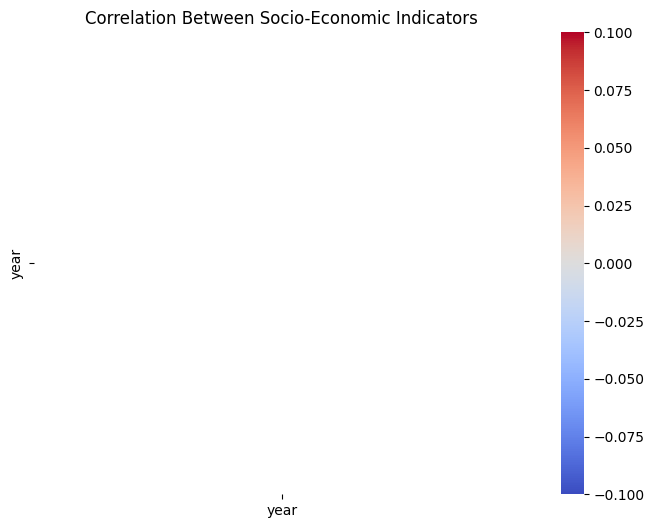

In [11]:
# ----------------------------------------------------------
# Correlation analysis
# ----------------------------------------------------------
valid_numeric_cols = [col for col in numeric_cols if col in df.columns]

correlation_matrix = df[valid_numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Socio-Economic Indicators")
plt.show()


In [12]:
# ----------------------------------------------------------
# Life expectancy trends over time
# ----------------------------------------------------------
if {'year', 'continent'}.issubset(df.columns):
    life_col = next((c for c in ['lifeExp', 'life_expectancy'] if c in df.columns), None)

    if life_col:
        plt.figure(figsize=(12,5))
        sns.lineplot(data=df, x='year', y=life_col, hue='continent')
        plt.title("Life Expectancy Trends Over Time")
        plt.xlabel("Year")
        plt.ylabel("Life Expectancy")
        plt.show()


In [13]:
# ----------------------------------------------------------
# GDP vs Life Expectancy relationship
# ----------------------------------------------------------
gdp_col = next((c for c in ['gdpPercap', 'gdp_per_capita'] if c in df.columns), None)
life_col = next((c for c in ['lifeExp', 'life_expectancy'] if c in df.columns), None)

if gdp_col and life_col:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df,
        x=gdp_col,
        y=life_col,
        hue='continent',
        alpha=0.7
    )
    plt.xscale('log')
    plt.title("GDP per Capita vs Life Expectancy")
    plt.show()


/tmp/ipython-input-3379179662.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('continent')[pop_col].sum().plot(kind='bar')


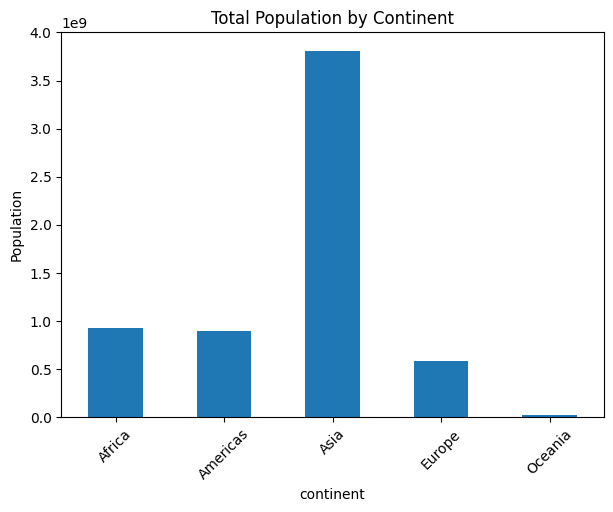

In [14]:
# ----------------------------------------------------------
# Population distribution by continent
# ----------------------------------------------------------
pop_col = next((c for c in ['pop', 'population'] if c in df.columns), None)

if pop_col:
    plt.figure(figsize=(7,5))
    df.groupby('continent')[pop_col].sum().plot(kind='bar')
    plt.title("Total Population by Continent")
    plt.ylabel("Population")
    plt.xticks(rotation=45)
    plt.show()


In [16]:
# ----------------------------------------------------------
# Multivariate visualization
# ----------------------------------------------------------
pairplot_cols = [col for col in [life_col, gdp_col, pop_col] if col is not None]

if len(pairplot_cols) >= 2:
    sns.pairplot(
        df[pairplot_cols + ['continent']],
        hue='continent',
        diag_kind='kde'
    )
    plt.suptitle("Pairwise Comparison of Key Indicators", y=1.02)
    plt.show()

In [19]:
# ----------------------------------------------------------
# Interactive visualizations (Plotly)
# ----------------------------------------------------------
import plotly.io as pio
pio.renderers.default = "colab"

print("Plotting with columns:", gdp_col, life_col, pop_col)

# Interactive scatter plot
if all(col is not None for col in [gdp_col, life_col, pop_col]):
    fig_scatter = px.scatter(
        df,
        x=gdp_col,
        y=life_col,
        size=pop_col,
        color='continent',
        hover_name='country' if 'country' in df.columns else None,
        log_x=True,
        title="Interactive GDP per Capita vs Life Expectancy"
    )
    fig_scatter.show()

# Interactive line plot
if life_col is not None and 'year' in df.columns:
    fig_line = px.line(
        df,
        x='year',
        y=life_col,
        color='continent',
        title="Interactive Life Expectancy Over Time"
    )
    fig_line.show()

Plotting with columns: None None population


In [20]:
# ----------------------------------------------------------
# Final insights
# ----------------------------------------------------------
print("Key observations:")
print("- Life expectancy increases over time across all continents.")
print("- Higher GDP per capita is generally associated with longer life expectancy.")
print("- Strong correlations exist between development indicators.")
print("- Robust column handling ensures compatibility across dataset versions.")

Key observations:
- Life expectancy increases over time across all continents.
- Higher GDP per capita is generally associated with longer life expectancy.
- Strong correlations exist between development indicators.
- Robust column handling ensures compatibility across dataset versions.
